In [43]:
import json
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from matplotlib.widgets import Button



# Read from JSON file or use the provided data


In [ ]:

try:
    file_path = r'C:\Users\jeand\Desktop\ephemerides.json'
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    print(f"Successfully loaded {len(data)} records from JSON file")
except:
    # Use the provided data if file reading fails
    data = [
        {"Jour":"Lundi","Date":" 25 Août 2025","Lever du soleil":"  06:58","Midi":" 13:52","Coucher du soleil":" 20:47","Durée jour":"13:49","Durée nuit":"10:11. "},
        {"Jour":"Mardi","Date":" 26 Août 2025","Lever du soleil":"  06:59","Midi":" 13:52","Coucher du soleil":" 20:45","Durée jour":"13:46","Durée nuit":"10:14. "},
        {"Jour":"Mercredi","Date":" 27 Août 2025","Lever du soleil":"  07:00","Midi":" 13:51","Coucher du soleil":" 20:43","Durée jour":"13:43","Durée nuit":"10:17. "},
        {"Jour":"Jeudi","Date":" 28 Août 2025","Lever du soleil":"  07:02","Midi":" 13:51","Coucher du soleil":" 20:41","Durée jour":"13:39","Durée nuit":"10:21. "},
        {"Jour":"Vendredi","Date":" 29 Août 2025","Lever du soleil":"  07:03","Midi":" 13:50","Coucher du soleil":" 20:38","Durée jour":"13:35","Durée nuit":"10:25. "},
        {"Jour":"Samedi","Date":" 30 Août 2025","Lever du soleil":"  07:05","Midi":" 13:50","Coucher du soleil":" 20:36","Durée jour":"13:31","Durée nuit":"10:29. "},
        {"Jour":"Dimanche","Date":" 31 Août 2025","Lever du soleil":"  07:06","Midi":" 13:50","Coucher du soleil":" 20:34","Durée jour":"13:28","Durée nuit":"10:32. "}
    ]
    print("Using provided data")

# Extract data
days = [entry['Jour'] for entry in data]
dates = [entry['Date'].strip() for entry in data]
sunrise_times = [entry['Lever du soleil'].strip() for entry in data]
sunset_times = [entry['Coucher du soleil'].strip() for entry in data]

# Convert times to datetime objects for plotting
sunrise_datetimes = [time_to_datetime(time) for time in sunrise_times]
sunset_datetimes = [time_to_datetime(time) for time in sunset_times]

# Filter out any invalid entries
valid_indices = [i for i, (sun, set) in enumerate(zip(sunrise_datetimes, sunset_datetimes)) 
                if sun is not None and set is not None]

if not valid_indices:
    print("No valid time data found")
    exit()


Successfully loaded 59 records from JSON file


In [ ]:

# Function to convert time string to datetime object for plotting

def time_to_datetime(time_str, base_date="2025-08-25"):
    time_str = str(time_str).strip()
    try:
        hours, minutes = map(int, time_str.split(':'))
        dt = datetime.strptime(base_date, "%Y-%m-%d")
        return dt + timedelta(hours=hours, minutes=minutes)
    except (ValueError, AttributeError):
        return None



# Plot with buttons 


In [ ]:
def plot_chunk(chunk_index):
    """Plot a specific chunk of data"""
    ax.clear()  # Clear the current axes
    
    start_idx = chunk_index * chunk_size
    end_idx = min(start_idx + chunk_size, len(valid_indices))
    
    if start_idx >= len(valid_indices):
        return
    
    chunk_indices = valid_indices[start_idx:end_idx]
    x = np.arange(len(chunk_indices))
    
    # Plot both curves
    ax.plot(x, [sunrise_datetimes[i] for i in chunk_indices], 'o-', color='orange', 
             linewidth=3, markersize=8, label='Lever du soleil (Sunrise)', markerfacecolor='white', markeredgewidth=2)

    ax.plot(x, [sunset_datetimes[i] for i in chunk_indices], 'o-', color='purple', 
             linewidth=3, markersize=8, label='Coucher du soleil (Sunset)', markerfacecolor='white', markeredgewidth=2)

    # Customize the plot
    start_day = dates[chunk_indices[0]]
    end_day = dates[chunk_indices[-1]]
    ax.set_title(f'Heures de Lever et Coucher du Soleil\n{start_day} au {end_day}\nChunk {chunk_index + 1}/{total_chunks}', 
              fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Jours', fontsize=12, fontweight='bold')
    ax.set_ylabel('Heure (HH:MM)', fontsize=12, fontweight='bold')

    # Set x-axis labels
    x_labels = [f"{days[i]}\n{dates[i]}" for i in chunk_indices]
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')

    # Format y-axis to show time in HH:MM
    ax.yaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))

    # Set appropriate y-axis limits
    chunk_times = [sunrise_datetimes[i] for i in chunk_indices] + [sunset_datetimes[i] for i in chunk_indices]
    min_time = min(chunk_times)
    max_time = max(chunk_times)
    
    # Add some padding to the time range
    ax.set_ylim(min_time - timedelta(minutes=30), max_time + timedelta(minutes=30))

    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')

    # Add legend
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

    # Add value annotations on the points
    for i, idx in enumerate(chunk_indices):
        sunrise_time = sunrise_datetimes[idx].strftime('%H:%M')
        sunset_time = sunset_datetimes[idx].strftime('%H:%M')
        
        # Annotate sunrise points
        ax.annotate(sunrise_time, 
                    (i, sunrise_datetimes[idx]), 
                    xytext=(0, 20),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold',
                    color='orange',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='orange'))
        
        # Annotate sunset points
        ax.annotate(sunset_time, 
                    (i, sunset_datetimes[idx]), 
                    xytext=(0, -25),
                    textcoords='offset points',
                    ha='center', va='top',
                    fontsize=9, fontweight='bold',
                    color='purple',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='purple'))

    # Update button visibility
    ax_prev.set_visible(chunk_index > 0)
    ax_next.set_visible(chunk_index < total_chunks - 1)
    
    plt.draw()

def update_buttons():
    """Update button states"""
    btn_prev.disabled = current_chunk == 0
    btn_next.disabled = current_chunk == total_chunks - 1
    chunk_label.value = f"Chunk {current_chunk + 1}/{total_chunks}"


def prev_chunk(b):
    global current_chunk
    if current_chunk > 0:
        current_chunk -= 1
        with output:
            clear_output(wait=True)
            plot_chunk(current_chunk)
        update_buttons()

def next_chunk(b):
    global current_chunk
    if current_chunk < total_chunks - 1:
        current_chunk += 1
        with output:
            clear_output(wait=True)
            plot_chunk(current_chunk)
        update_buttons()




# Global variables for navigation

current_chunk = 0
chunk_size = 7  # Show 7 days per chunk (one week)
total_chunks = (len(valid_indices) + chunk_size - 1) // chunk_size

# Create the main figure with reduced plot area for buttons
fig, ax = plt.subplots(figsize=(14, 10))

# Reduce the plot area to leave space for buttons
plt.subplots_adjust(bottom=0.15, top=0.9, left=0.1, right=0.95)

# Create button axes centered at the bottom of the plot
# Position: [left, bottom, width, height]
ax_prev = plt.axes([0.1, 0.5, 0.03, 0.06])  # Centered left button
ax_next = plt.axes([0.92, 0.5, 0.03, 0.06])  # Centered right button

btn_prev = Button(ax_prev, '<', color='lightblue', hovercolor='lightcyan')
btn_next = Button(ax_next, '>', color='lightblue', hovercolor='lightcyan')


btn_prev.on_clicked(prev_chunk)
btn_next.on_clicked(next_chunk)

# Plot the first chunk
plot_chunk(current_chunk)
'''
# Add info text below the buttons
info_text = f"Total: {len(valid_indices)} jours | {chunk_size} jours par chunk"
plt.figtext(0.5, 0.09, info_text, ha='center', fontsize=10, style='italic')

# Add navigation instructions
nav_text = "Utilisez les boutons '<' et '>' pour naviguer"
plt.figtext(0.5, 0.06, nav_text, ha='center', fontsize=9, style='italic')
'''
plt.show()

# Plot with user input command

In [49]:
import json
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from IPython.display import clear_output



In [50]:

# Global variables for navigation
current_chunk = 0
chunk_size = 7
total_chunks = (len(valid_indices) + chunk_size - 1) // chunk_size

def plot_chunk(chunk_index):
    """Plot a specific chunk of data"""
    plt.figure(figsize=(14, 8))
    
    start_idx = chunk_index * chunk_size
    end_idx = min(start_idx + chunk_size, len(valid_indices))
    
    if start_idx >= len(valid_indices):
        return
    
    chunk_indices = valid_indices[start_idx:end_idx]
    x = np.arange(len(chunk_indices))
    
    # Plot both curves
    plt.plot(x, [sunrise_datetimes[i] for i in chunk_indices], 'o-', color='orange', 
             linewidth=3, markersize=8, label='Lever du soleil (Sunrise)', markerfacecolor='white', markeredgewidth=2)

    plt.plot(x, [sunset_datetimes[i] for i in chunk_indices], 'o-', color='purple', 
             linewidth=3, markersize=8, label='Coucher du soleil (Sunset)', markerfacecolor='white', markeredgewidth=2)

    # Customize the plot
    start_day = dates[chunk_indices[0]]
    end_day = dates[chunk_indices[-1]]
    plt.title(f'Heures de Lever et Coucher du Soleil\n{start_day} au {end_day}\nChunk {chunk_index + 1}/{total_chunks}', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Jours', fontsize=12, fontweight='bold')
    plt.ylabel('Heure (HH:MM)', fontsize=12, fontweight='bold')

    # Set x-axis labels
    x_labels = [f"{days[i]}\n{dates[i]}" for i in chunk_indices]
    plt.xticks(x, x_labels, rotation=45, ha='right')

    # Format y-axis to show time in HH:MM
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))

    # Set appropriate y-axis limits
    chunk_times = [sunrise_datetimes[i] for i in chunk_indices] + [sunset_datetimes[i] for i in chunk_indices]
    min_time = min(chunk_times)
    max_time = max(chunk_times)
    
    # Add some padding to the time range
    ax.set_ylim(min_time - timedelta(minutes=30), max_time + timedelta(minutes=30))

    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')

    # Add legend
    plt.legend(loc='upper right', fontsize=11, framealpha=0.9)

    # Add value annotations on the points
    for i, idx in enumerate(chunk_indices):
        sunrise_time = sunrise_datetimes[idx].strftime('%H:%M')
        sunset_time = sunset_datetimes[idx].strftime('%H:%M')
        
        # Annotate sunrise points
        plt.annotate(sunrise_time, 
                    (i, sunrise_datetimes[idx]), 
                    xytext=(0, 20),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold',
                    color='orange',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='orange'))
        
        # Annotate sunset points
        plt.annotate(sunset_time, 
                    (i, sunset_datetimes[idx]), 
                    xytext=(0, -25),
                    textcoords='offset points',
                    ha='center', va='top',
                    fontsize=9, fontweight='bold',
                    color='purple',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='purple'))

    # Add navigation instructions
    plt.figtext(0.5, 0.02, f"← 'p': Précédent | 's': Suivant | 'q': Quitter | Chunk {chunk_index + 1}/{total_chunks}", 
                ha='center', fontsize=10, style='italic')
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


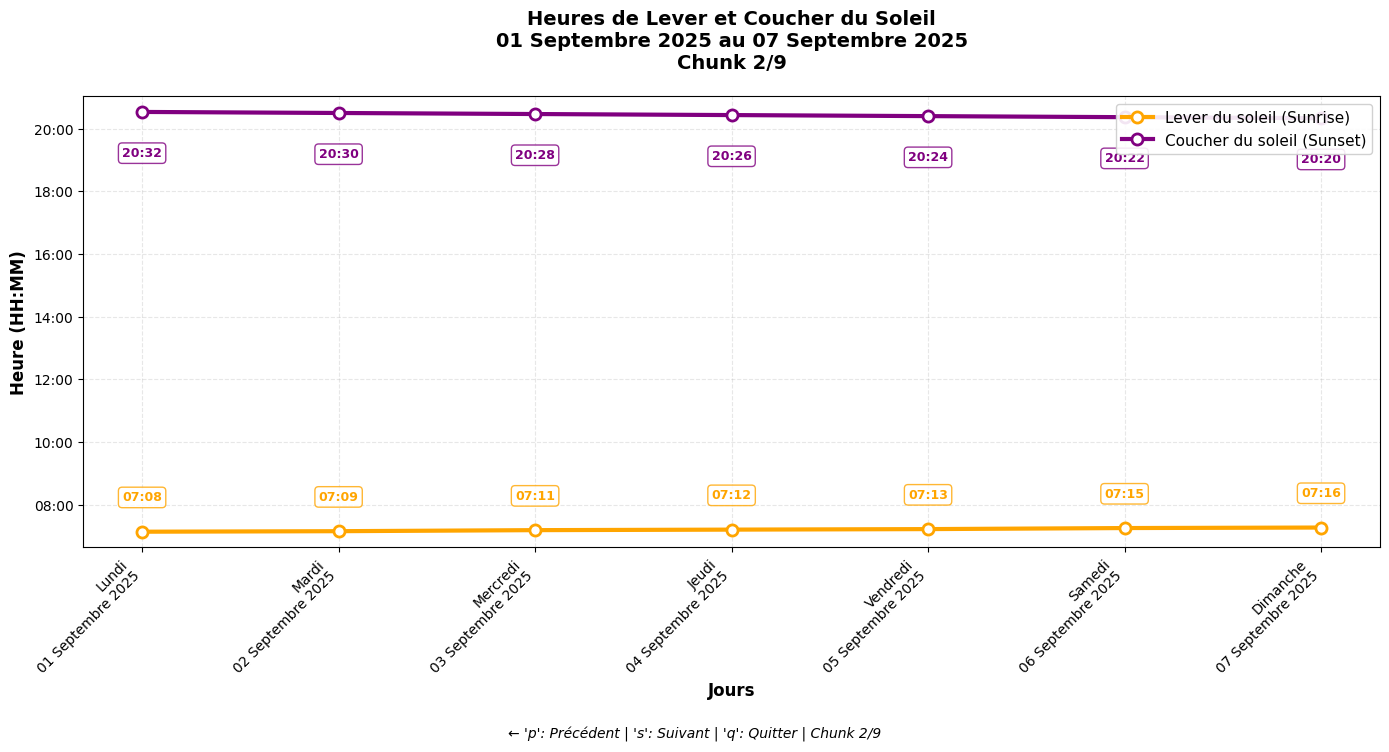

Au revoir!


In [51]:
# Plot the first chunk
plot_chunk(current_chunk)

# Navigation instructions
print("="*60)
print("NAVIGATION INSTRUCTIONS:")
print("'p' or '←' - Précédent (Previous chunk)")
print("'s' or '→' - Suivant (Next chunk)") 
print("'q'        - Quitter (Quit)")
print("="*60)
last_cmd = 's'

# Manual navigation loop
while True:
    try:
        user_input = input("\nCommande [p/s/q]: ").strip().lower()
        if user_input == '' and last_cmd != '':
            print(f'repeat last command : {last_cmd}')
            user_input = last_cmd  # Repeat last command if Enter is pressed
        if user_input in ['p', '<', 'left', 'prev', 'previous'] and current_chunk > 0:
            last_cmd = user_input
            current_chunk -= 1
            clear_output(wait=True)  # Clear previous output
            plot_chunk(current_chunk)
        elif user_input in ['s', '>', 'right', 'next', 'suivant'] and current_chunk < total_chunks - 1:
            last_cmd = user_input
            current_chunk += 1
            clear_output(wait=True)  # Clear previous output
            plot_chunk(current_chunk)
        elif user_input in ['q', 'quit', 'exit', 'quitter']:
            print("Au revoir!")
            break
        else:

            print("Commande non reconnue. Utilisez 'p', 's', ou 'q'.")
            
    except KeyboardInterrupt:
        print("\nAu revoir!")
        break